In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
history.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [4]:
history['Date'] = pd.to_datetime(history['Date'])


In [5]:
history = history.sort_values('Date')


In [6]:
history.isna().sum()


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [12]:
history.ffill(inplace=True)


In [16]:
history['Daily_Return_%'] = history['Close'].pct_change() * 100


In [18]:
history['MA_7'] = history['Close'].rolling(window=7).mean()
history['MA_30'] = history['Close'].rolling(window=30).mean()


In [19]:
history['Volatility_7'] = history['Daily_Return_%'].rolling(window=7).std()


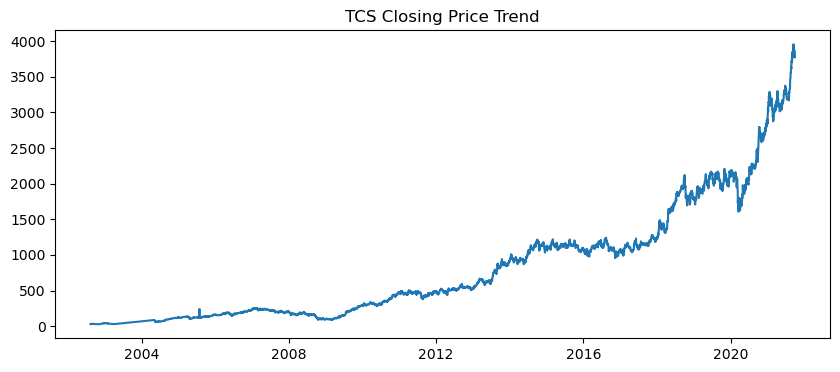

In [20]:
plt.figure(figsize=(10,4))
plt.plot(history['Date'], history['Close'])
plt.title("TCS Closing Price Trend")
plt.show()


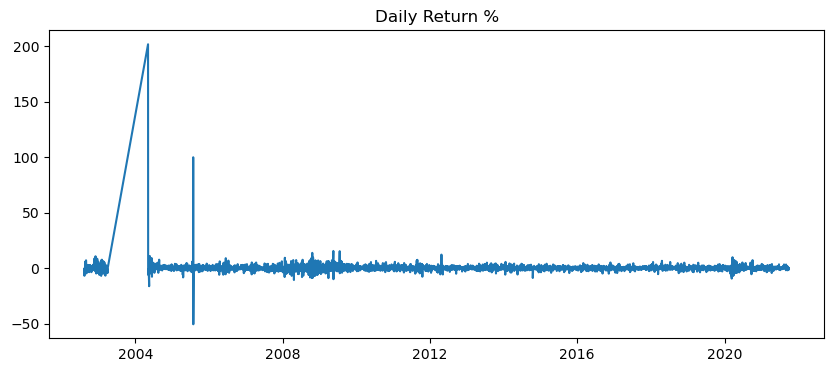

In [21]:
plt.figure(figsize=(10,4))
plt.plot(history['Date'], history['Daily_Return_%'])
plt.title("Daily Return %")
plt.show()


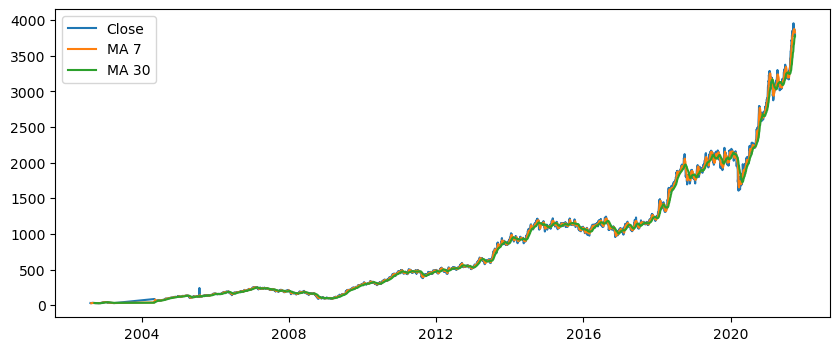

In [22]:
plt.figure(figsize=(10,4))
plt.plot(history['Date'], history['Close'], label='Close')
plt.plot(history['Date'], history['MA_7'], label='MA 7')
plt.plot(history['Date'], history['MA_30'], label='MA 30')
plt.legend()
plt.show()


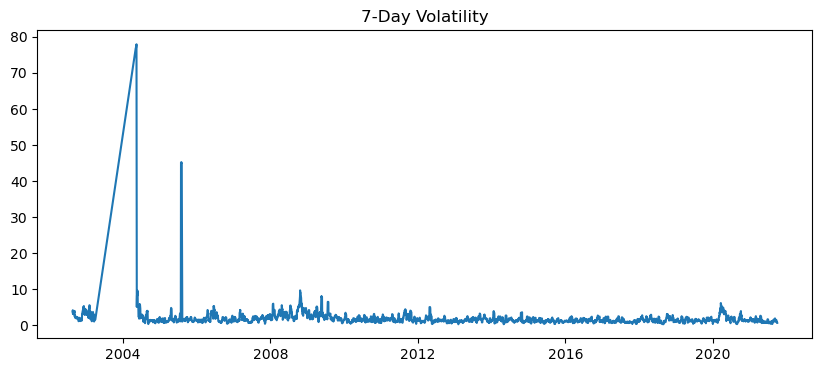

In [23]:
plt.figure(figsize=(10,4))
plt.plot(history['Date'], history['Volatility_7'])
plt.title("7-Day Volatility")
plt.show()


In [27]:
# Assistant
import os

# Create the output directory if it doesn't exist
if not os.path.exists("output"):
    os.makedirs("output")
    
# Now save the file
history.to_csv("output/cleaned_tcs_stock.csv", index=False)

# Assistant
The error occurs because the code is trying to read an Excel file from a path that doesn't exist. The file "cleaned_tcs_stock.xls" is not found in the "output" directory.

There are a few possible solutions:

1. Make sure the file path is correct
2. Create the "output" directory if it doesn't exist
3. Check if the file exists before trying to read it

Would you like me to provide the corrected code?

# User
YES

In [30]:
# Assistant
import pandas as pd
import os

# Create output directory if it doesn't exist
os.makedirs("output", exist_ok=True)

try:
    # Check if file exists
    file_path = "output/cleaned_tcs_stock.xls"
    if os.path.exists(file_path):
        # Read Excel file
        df = pd.read_excel(file_path)
        
        # Save as CSV
        df.to_csv("output/cleaned_tcs_stock.csv", index=False)
        print("CSV file created successfully")
    else:
        print(f"Error: File '{file_path}' does not exist.")
        # You might want to provide the correct path here
        print("Please check the file path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: File 'output/cleaned_tcs_stock.xls' does not exist.
Please check the file path and try again.


In [31]:
import os
os.listdir("output")


['.ipynb_checkpoints', 'cleaned_tcs_stock.csv']

In [32]:
import os
import pandas as pd

# make sure output folder exists
if not os.path.exists("output"):
    os.makedirs("output")

# save directly as CSV (we skip Excel now to avoid confusion)
history.to_csv("output/cleaned_tcs_stock.csv", index=False)

print("File saved")


File saved


In [33]:
os.listdir("output")


['.ipynb_checkpoints', 'cleaned_tcs_stock.csv']